Используя базу данных автомобилей, создайте сеть с точностью распознавания не ниже 93% на проверочной выборке.

Для решения задачи вы можете использовать любой подход:
- модель без аугментации данных
- аугментация данных с помощью ImageDataGenerator
- аугментация данных с помощью самописного генератора изображений
- использовать готовую архитектуру из набора `tf.keras.applications` (Обратите внимание: на занятии мы не рассматривали данный модуль фреймворка Керас. Ваша задача: попробовать самостоятельно разобраться в приципах его работы. В разборе домашнего задания вы получите ссылку на ноутбук Базы Знаний УИИ, где подробно раскрывается вопрос использования готовых архитектур)

## 1. Установка kagglehub

In [6]:
!pip install kagglehub -q

## 2. Импорт библиотек

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import kagglehub
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

## 3. Загрузка датасета

In [16]:
# скачиваем датасет
path = kagglehub.dataset_download("kshitij192/cars-image-dataset")
print("Путь к датасету:", path)

# смотрим структуру
print("Содержимое:", os.listdir(path))

# ищем папки train и test
if 'train' in os.listdir(path):
    TRAIN_PATH = os.path.join(path, 'train')
    TEST_PATH = os.path.join(path, 'test')
else:
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            if 'train' in os.listdir(folder_path):
                TRAIN_PATH = os.path.join(folder_path, 'train')
                TEST_PATH = os.path.join(folder_path, 'test')
                break
    else:
        TRAIN_PATH = path
        TEST_PATH = path

print(f"\nTrain путь: {TRAIN_PATH}")
print(f"Test путь: {TEST_PATH}")
print("Классы в train:", os.listdir(TRAIN_PATH) if os.path.exists(TRAIN_PATH) else "не найдено")

Using Colab cache for faster access to the 'cars-image-dataset' dataset.
Путь к датасету: /kaggle/input/cars-image-dataset
Содержимое: ['Cars Dataset']

Train путь: /kaggle/input/cars-image-dataset/Cars Dataset/train
Test путь: /kaggle/input/cars-image-dataset/Cars Dataset/test
Классы в train: ['Hyundai Creta', 'Tata Safari', 'Swift', 'Mahindra Scorpio', 'Toyota Innova', 'Rolls Royce', 'Audi']


## 4. Визуализация примеров изображений

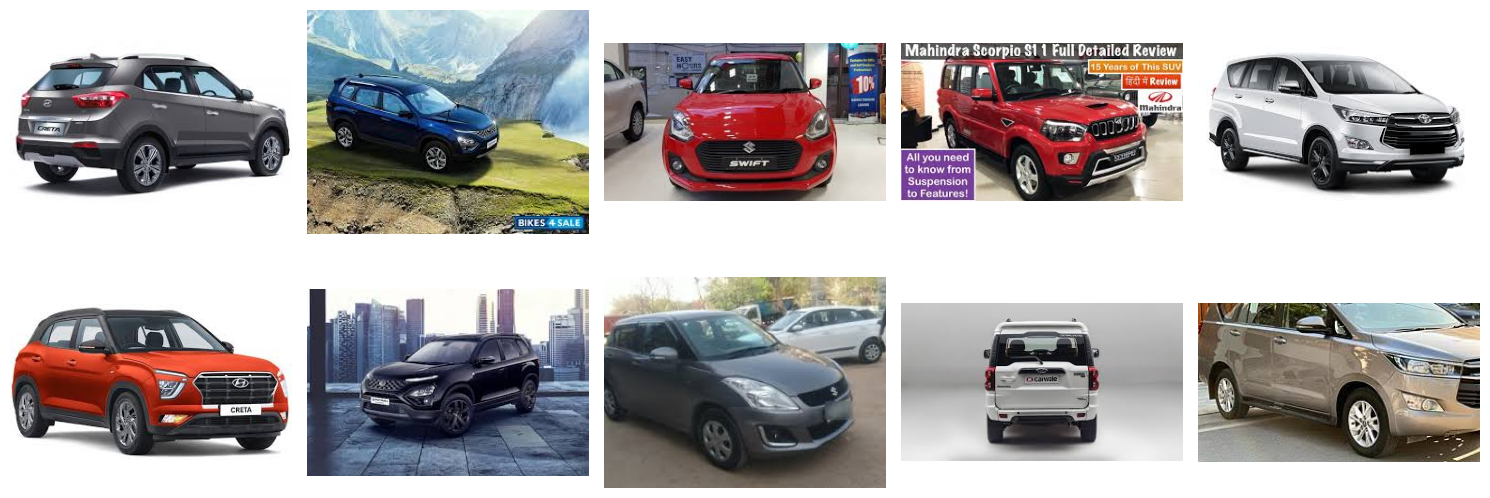

In [19]:
classes = [d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))]

fig, axs = plt.subplots(2, min(5, len(classes)), figsize=(15, 6))

for i, class_name in enumerate(classes[:5]):
    class_path = os.path.join(TRAIN_PATH, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    if len(images) > 0:
        img_path = os.path.join(class_path, random.choice(images))
        img = Image.open(img_path)
        axs[0, i].imshow(img)
        axs[0, i].axis('off')

        if len(images) > 1:
            img2_path = os.path.join(class_path, random.choice(images))
            img2 = Image.open(img2_path)
            axs[1, i].imshow(img2)
            axs[1, i].axis('off')

plt.tight_layout()
plt.show()

## 5. Генераторы данных

In [25]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
EPOCHS = 10

# аугментация для тренировочных данных
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # выделяем валидацию из train
)

# для валидации и теста только нормализация
test_datagen = ImageDataGenerator(rescale=1./255)

# генераторы
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH if os.path.exists(TEST_PATH) else TRAIN_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print(f"Количество классов: {NUM_CLASSES}")
print(f"Метки классов: {train_generator.class_indices}")

Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Found 813 images belonging to 7 classes.
Количество классов: 7
Метки классов: {'Audi': 0, 'Hyundai Creta': 1, 'Mahindra Scorpio': 2, 'Rolls Royce': 3, 'Swift': 4, 'Tata Safari': 5, 'Toyota Innova': 6}


## 6. Создание модели MobileNetV2

In [26]:
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# замораживаем базовую модель
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Первый этап обучения (замороженная база)

In [27]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

history1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 84s 388ms/step - accuracy: 0.4203 - loss: 1.6097 - val_accuracy: 0.5898 - val_loss: 1.0853
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 257ms/step - accuracy: 0.5849 - loss: 1.1741 - val_accuracy: 0.7171 - val_loss: 0.8722
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 261ms/step - accuracy: 0.6520 - loss: 1.0079 - val_accuracy: 0.7320 - val_loss: 0.7772
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 258ms/step - accuracy: 0.6803 - loss: 0.9408 - val_accuracy: 0.7440 - val_loss: 0.7053
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 255ms/step - accuracy: 0.7001 - loss: 0.8722 - val_accuracy: 0.7590 - val_loss: 0.6811
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 261ms/step - accuracy: 0.7291 - loss: 0.7899 - val_accuracy: 0.7710 - val_loss: 0.6536
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 255ms/step - accuracy: 0.7187 - loss: 0.8039 - val_accuracy: 0.7934 - val_loss: 0.6284
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 261ms/step - accuracy: 0.7496 - loss: 0

## 8. Второй этап обучения (разморозка 30 слоёв)

In [ ]:
# размораживаем 30 слоёв
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# перекомпилируем с меньшим learning rate
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

history2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 78s 365ms/step - accuracy: 0.7120 - loss: 0.8557 - val_accuracy: 0.8084 - val_loss: 0.6284 - learning_rate: 1.0000e-04
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 263ms/step - accuracy: 0.8025 - loss: 0.6056 - val_accuracy: 0.7859 - val_loss: 0.7986 - learning_rate: 1.0000e-04
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 258ms/step - accuracy: 0.8536 - loss: 0.4426 - val_accuracy: 0.6781 - val_loss: 1.7318 - learning_rate: 1.0000e-04
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 45s 267ms/step - accuracy: 0.8770 - loss: 0.3970 - val_accuracy: 0.8578 - val_loss: 0.5864 - learning_rate: 1.0000e-04
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 256ms/step - accuracy: 0.8931 - loss: 0.3669 - val_accuracy: 0.8204 - val_loss: 0.8219 - learning_rate: 1.0000e-04
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 259ms/step - accuracy: 0.9080 - loss: 0.2866 - val_accuracy: 0.7844 - val_loss: 0.6460 - learning_rate: 1.0000e-04
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 26

## 9. Третий этап обучения (разморозка 50 слоёв)

In [ ]:
# размораживаем 50 слоев
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# ещё меньший learning rate
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00001),
    metrics=['accuracy']
)

history3 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 78s 364ms/step - accuracy: 0.9475 - loss: 0.1779 - val_accuracy: 0.9162 - val_loss: 0.2866
Epoch 2/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 261ms/step - accuracy: 0.9620 - loss: 0.1393 - val_accuracy: 0.9177 - val_loss: 0.2336
Epoch 3/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 261ms/step - accuracy: 0.9534 - loss: 0.1454 - val_accuracy: 0.9117 - val_loss: 0.2415
Epoch 4/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 43s 257ms/step - accuracy: 0.9601 - loss: 0.1350 - val_accuracy: 0.9386 - val_loss: 0.1904
Epoch 5/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 264ms/step - accuracy: 0.9605 - loss: 0.1270 - val_accuracy: 0.9401 - val_loss: 0.1963


## 10. График обучения и точность

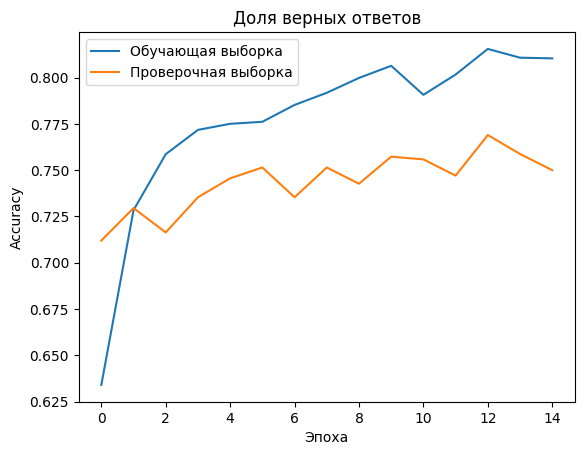

Точность на проверочной выборке: 0.9491 (94.91%)


In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
plt.title('Доля верных ответов')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"Точность на проверочной выборке: {val_acc:.4f} ({val_acc*100:.2f}%)")

## 11. Визуализация предсказаний модели

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


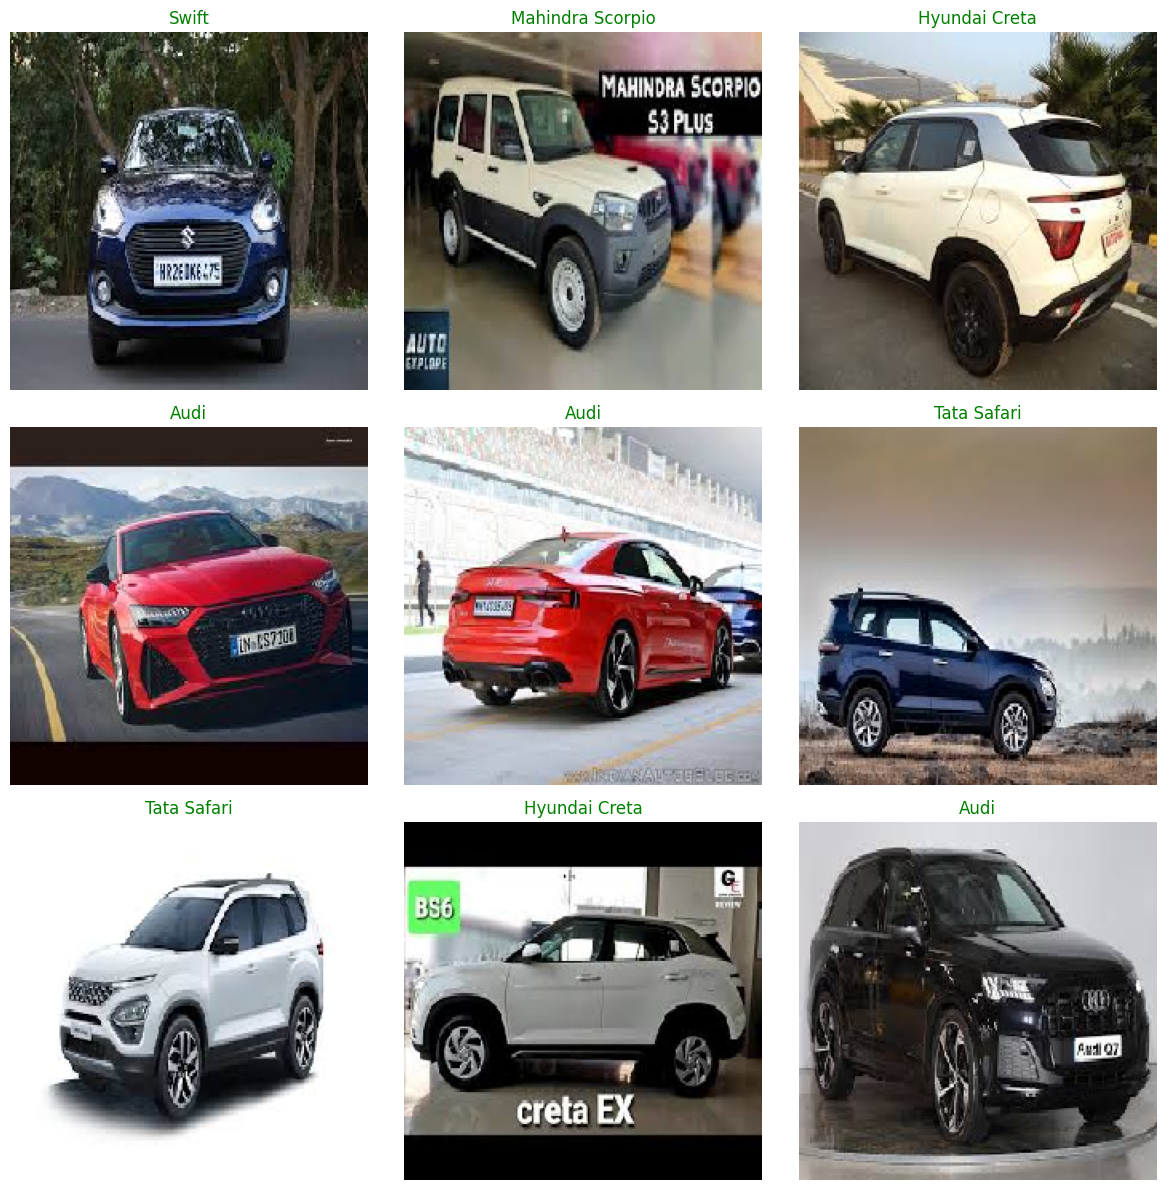

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import random

test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for i in range(9):
    idx = random.randint(0, len(y_true) - 1)

    test_generator.reset()
    for j, (img, label) in enumerate(test_generator):
        if j == idx // test_generator.batch_size:
            img_idx = idx % test_generator.batch_size
            axes[i].imshow(img[img_idx])
            break

    axes[i].axis('off')

    pred = class_names[y_pred_classes[idx]]
    true = class_names[y_true[idx]]
    correct = pred == true

    axes[i].set_title(f'{pred}', color='green' if correct else 'red', fontsize=12)

plt.tight_layout()
plt.show()